In [111]:
import sys
import os

sys.path.append('/scratch2/mrenaudin/colorlessgreenRNNs')

import torch
from wm_tests.utils import CBR_RNN_attn_tracking
from src.language_models.dictionary_corpus import Dictionary
from evaluation_notebooks.utils import NounPPDataset, collate_fn_nounpp
from torch.utils.data import DataLoader
from collections import defaultdict
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
from collections import defaultdict
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np


# Méthode 
1. Construire un test set :
-   features : hidden state et attention du modèle durant le processing de toutes les phrases 
-   target : sujet de la phrase (ou attracteur) -> facile c'est toujours à la même position
2. Le modèle : binary classification
3. Expérience :  le sujet de la phrase devrait être décodable facilement au moment ou il apparait et au momemt de conjuguer le verbe car ce sont les deux endroits ou l'information est importante

In [ ]:
#model
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CBR_RNN_attn_tracking(50001, 650, 650, 1, device = device)
checkpoint = torch.load('/scratch2/mrenaudin/colorlessgreenRNNs/checkpoints/test_attention_650/epoch_38.pt', map_location=device)
temperature = checkpoint['epoch']
model.load_state_dict(checkpoint['model_state_dict'])

<All keys matched successfully>

In [15]:
#NounPP dataset
nounpp = '/scratch2/mrenaudin/colorlessgreenRNNs/NounPP/Stimuli/nounpp.txt'
data = '/scratch2/mrenaudin/colorlessgreenRNNs/english_data'
dictionary = Dictionary(data)
dataset = NounPPDataset(nounpp, dictionary)
dataloader = DataLoader(dataset, batch_size=1000, collate_fn=collate_fn_nounpp)

In [33]:
def eval(model, test_dataloader, temperature):
    condition_accuracies = defaultdict(int)
    condition_counts = defaultdict(int)
    correct_pred = 0
    sentence_details = []
    model.eval()
    features = {}
    features['hidden']=[]
    features['attention']= []
    features['condition']=[]
    # Forward pass with hidden state update word by word
    with torch.no_grad():
        for batch in test_dataloader:
            out = None
            written = batch["sentence"]
            sentence = batch["encoded_sentence"]
            correct = batch["encoded_correct"]
            wrong = batch["encoded_wrong"]
            condition = batch["condition"]
            batch_size = sentence.size(0)
            features['condition'].append(condition)
            sent = sentence.transpose(0, 1)
            cache = model.init_cache(sent,1)  # regarder si on peut mettre du priming
            # for i in range(sent.shape[1]):
            out, hidden, attention= model(sent, cache, 1, temperature, True)
            features['hidden'].append(hidden[1:])
            features['attention'].append(attention)
            log_probs = torch.nn.functional.log_softmax(
                out, dim=-1
            )  # s(out.squeeze(0))
            # déja sur correct et wrong log probs, pas les même résultats que sur extract_predictions.py
            correct_log_probs = log_probs[
                -1, torch.arange(batch_size), correct
            ]  # Shape: [512]
            wrong_log_probs = log_probs[-1, torch.arange(batch_size), wrong]
            correct_predictions = correct_log_probs >= wrong_log_probs

            for i in range(batch_size):
                cond = condition[i]
                pred = correct_predictions[i].item()  # Convert tensor to Python boolean
                condition_counts[cond] += 1
                condition_accuracies[cond] += pred

                sentence_details.append(
                    {
                        "sentence": written[i],
                        "condition": condition[i],
                        "correct_log_prob": correct_log_probs[i],
                        "wrong_log_prob": wrong_log_probs[i],
                        "model_prefers_correct": pred,
                    }
                )

    final_accuracies = {
        cond: condition_accuracies[cond] / condition_counts[cond]
        for cond in condition_accuracies
    }
    return final_accuracies, features

In [34]:
acc, features = eval(model, dataloader, temperature)

In [98]:
targets = []
for i in range(len(dataset)):
    target = torch.zeros_like(dataset[1]['encoded_sentence'])
    target[1]=1
    targets.append(target)


# Within condition decoding : train-test split within each condition

## Predicting from hidden state

In [170]:
def prepare_features_and_targets(features, targets):
    """
    Prepare features and targets for logistic regression by condition.
    
    Args:
        features: Dictionary with 'hidden', 'attention', 'condition' keys
        targets: List of target tensors (one per sentence)
        dataset: Original dataset to get sentence lengths
    
    Returns:
        Dictionary with condition as key and (X, y) as values
    """
    # Convert features to proper format
    hidden_states = torch.cat(features['hidden'], dim=1)  # Shape: [seq_len, total_samples, hidden_dim]
    conditions = []
    for cond_batch in features['condition']:
        conditions.extend(cond_batch)
    
    # Group by condition
    condition_data = defaultdict(lambda: {'X': [], 'y': []})
    
    sample_idx = 0
    for batch_conditions in features['condition']:
        batch_size = len(batch_conditions)
        
        for i in range(batch_size):
            condition = batch_conditions[i]
            
            # Extract hidden states for this sample (all positions)
            sample_hidden = hidden_states[:, sample_idx, :].cpu().numpy()  # [seq_len, hidden_dim]
            
            # Extract target for this sample
            target = targets[sample_idx].cpu().numpy()  # [seq_len]
            
            # Add to condition group
            condition_data[condition]['X'].append(sample_hidden)
            condition_data[condition]['y'].append(target)
            
            sample_idx += 1
    
    # Convert lists to arrays for each condition
    for condition in condition_data:
        condition_data[condition]['X'] = np.array(condition_data[condition]['X'])
        condition_data[condition]['y'] = np.array(condition_data[condition]['y'])
    
    return condition_data

In [212]:
def train_logistic_regression_by_condition(condition_data, test_size=0.2, random_state=42):
    """
    Train logistic regression for each condition to predict subject position.
    Reshapes data so each word position becomes a separate sample.
    
    Args:
        condition_data: Dictionary with condition as key and (X, y) as values
        test_size: Fraction of data to use for testing
        random_state: Random seed for reproducibility
    
    Returns:
        Dictionary with results for each condition
    """
    results = {}
    
    for condition, data in condition_data.items():
        print(f"\nProcessing condition: {condition}")
        
        X = data['X']  # Shape: [n_samples, seq_len, hidden_dim]
        y = data['y']  # Shape: [n_samples, seq_len]
        
        n_samples, seq_len, hidden_dim = X.shape
        print(f"  Samples: {n_samples}, Sequence length: {seq_len}, Hidden dim: {hidden_dim}")
        
        # Reshape data: treat each word position as a separate sample
        # This creates variation in labels (some positions are subjects, others are not)
        X_reshaped = X.reshape(-1, hidden_dim)  # [n_samples * seq_len, hidden_dim]
        y_reshaped = y.reshape(-1)              # [n_samples * seq_len]
        sentence_indices = np.repeat(np.arange(n_samples), seq_len)
        print(f"  After reshaping: {X_reshaped.shape[0]} word samples")
        print(f"  Label distribution: {np.bincount(y_reshaped.astype(int))} (0: not subject, 1: subject)")
        
        # Check if we have variation in labels
        if len(np.unique(y_reshaped)) < 2:
            print(f"  Skipping condition {condition} - no label variation")
            continue
        
        train_sentences, test_sentences = train_test_split(
            np.arange(n_samples), test_size=test_size, random_state=random_state
        )
        train_mask = np.isin(sentence_indices, train_sentences)
        test_mask = np.isin(sentence_indices, test_sentences)

        # Extract train/test sets
        X_train, y_train = X_reshaped[train_mask], y_reshaped[train_mask]
        X_test, y_test = X_reshaped[test_mask], y_reshaped[test_mask]
        sentence_indices_test = sentence_indices[test_mask]

        # Word-level shuffling
        train_perm = np.random.RandomState(seed=random_state).permutation(len(X_train))
        test_perm = np.random.RandomState(seed=random_state + 1).permutation(len(X_test))
        
        X_train, y_train = X_train[train_perm], y_train[train_perm]
        X_test, y_test = X_test[test_perm], y_test[test_perm]
        sentence_indices_test = sentence_indices_test[test_perm]
        
        print(f"  Train samples: {len(X_train)}, Test samples: {len(X_test)}")
        print(f"  Train label distribution: {np.bincount(y_train.astype(int))}")
        print(f"  Test label distribution: {np.bincount(y_test.astype(int))}")
        
        # Train logistic regression
        clf = LogisticRegression(random_state=random_state, max_iter=1000)
        clf.fit(X_train, y_train)
        
        # Predict on test set
        y_pred = clf.predict(X_test)
        y_pred_proba = clf.predict_proba(X_test)
        
        # Calculate metrics
        accuracy = accuracy_score(y_test, y_pred)
        
        # # Additional analysis: accuracy by position
        position_accuracies = {}
        for pos in range(seq_len):
            pos_correct = 0
            pos_total = 0
            for sent_idx in test_sentences:
                sent_positions = np.where(sentence_indices[test_mask] == sent_idx)[0]
                if len(sent_positions) > pos:
                    test_idx = sent_positions[pos]
                    if y_test[test_idx] == y_pred[test_idx]:
                        pos_correct += 1
                    pos_total += 1
                    
                    if pos_total > 0:
                        position_accuracies[pos] = pos_correct / pos_total
            
        results[condition] = {
            'classifier': clf,
            'accuracy': accuracy,
            'y_test': y_test,
            'y_pred': y_pred,
            'y_pred_proba': y_pred_proba,
            'n_train': len(X_train),
            'n_test': len(X_test),
            'position_accuracies': position_accuracies,
            'sentence_indices_test': sentence_indices[test_mask]
        }
        
        print(f"  Overall accuracy: {accuracy:.4f}")
        for pos, pos_acc in position_accuracies.items():
            marker = " *** SUBJECT POSITION ***" if pos == 1 else ""
            print(f"    Position {pos} accuracy: {pos_acc:.4f}{marker}")
    
    return results

In [213]:
res = train_logistic_regression_by_condition(condition_data, test_size=0.9, random_state=42)


Processing condition: singular singular
  Samples: 1000, Sequence length: 6, Hidden dim: 650
  After reshaping: 6000 word samples
  Label distribution: [5000 1000] (0: not subject, 1: subject)
  Train samples: 600, Test samples: 5400
  Train label distribution: [500 100]
  Test label distribution: [4500  900]
  Overall accuracy: 1.0000
    Position 0 accuracy: 1.0000
    Position 1 accuracy: 1.0000 *** SUBJECT POSITION ***
    Position 2 accuracy: 1.0000
    Position 3 accuracy: 1.0000
    Position 4 accuracy: 1.0000
    Position 5 accuracy: 1.0000

Processing condition: singular plural
  Samples: 1000, Sequence length: 6, Hidden dim: 650
  After reshaping: 6000 word samples
  Label distribution: [5000 1000] (0: not subject, 1: subject)
  Train samples: 600, Test samples: 5400
  Train label distribution: [500 100]
  Test label distribution: [4500  900]
  Overall accuracy: 1.0000
    Position 0 accuracy: 1.0000
    Position 1 accuracy: 1.0000 *** SUBJECT POSITION ***
    Position 2 acc

Even with 90% of each set as the test set, the accuracy is of 1 for each position and each class.

In [174]:

def analyze_results(results):
    """
    Analyze and visualize the results.
    """
    print("\n" + "="*50)
    print("SUMMARY RESULTS")
    print("="*50)
    
    # Collect data for visualization
    overall_accuracies = []
    conditions = []
    subject_accuracies = []
    
    for condition, metrics in results.items():
        print(f"\nCondition: {condition}")
        print("-" * 30)
        
        overall_acc = metrics['accuracy']
        print(f"  Overall accuracy: {overall_acc:.4f} (n_test={metrics['n_test']})")
        
        overall_accuracies.append(overall_acc)
        conditions.append(condition)
        
        # Position-specific accuracies
        if 'position_accuracies' in metrics:
            print("  Position-specific accuracies:")
            for pos, pos_acc in metrics['position_accuracies'].items():
                marker = " *** SUBJECT POSITION ***" if pos == 1 else ""
                print(f"    Position {pos}: {pos_acc:.4f}{marker}")
                
                if pos == 1:
                    subject_accuracies.append(pos_acc)
    
    # Create visualizations
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))
    
    # Plot 1: Overall accuracy by condition
    axes[0].bar(range(len(conditions)), overall_accuracies)
    axes[0].set_xlabel('Condition')
    axes[0].set_ylabel('Accuracy')
    axes[0].set_title('Overall Subject Detection Accuracy by Condition')
    axes[0].set_xticks(range(len(conditions)))
    axes[0].set_xticklabels(conditions, rotation=45)
    axes[0].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
    axes[0].grid(True, alpha=0.3)
    
    # Plot 2: Position-specific accuracies for each condition
    for condition, metrics in results.items():
        if 'position_accuracies' in metrics:
            pos_accs = metrics['position_accuracies']
            positions_list = sorted(pos_accs.keys())
            accuracies_list = [pos_accs[pos] for pos in positions_list]
            axes[1].plot(positions_list, accuracies_list, marker='o', label=condition, linewidth=2)
    
    axes[1].set_xlabel('Position')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('Subject Detection Accuracy by Position')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    axes[1].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
    
    # Highlight subject position (position 1)
    axes[1].axvline(x=1, color='green', linestyle='--', alpha=0.7, linewidth=2, label='Subject Position')
    
    # Plot 3: Subject position accuracy comparison
    if subject_accuracies and len(subject_accuracies) == len(conditions):
        bars = axes[2].bar(range(len(conditions)), subject_accuracies)
        axes[2].set_xlabel('Condition')
        axes[2].set_ylabel('Accuracy')
        axes[2].set_title('Subject Detection Accuracy (Position 1) by Condition')
        axes[2].set_xticks(range(len(conditions)))
        axes[2].set_xticklabels(conditions, rotation=45)
        axes[2].axhline(y=0.5, color='red', linestyle='--', alpha=0.5, label='Chance')
        axes[2].grid(True, alpha=0.3)
        
        # Color bars based on performance
        for i, bar in enumerate(bars):
            if subject_accuracies[i] > 0.7:
                bar.set_color('green')
            elif subject_accuracies[i] > 0.6:
                bar.set_color('orange')
            else:
                bar.set_color('red')
    
    plt.tight_layout()
    plt.show()
    
    return {
        'overall_accuracies': dict(zip(conditions, overall_accuracies)),
        'subject_accuracies': dict(zip(conditions, subject_accuracies)) if subject_accuracies else {}
    }



SUMMARY RESULTS

Condition: singular singular
------------------------------
  Overall accuracy: 1.0000 (n_test=5400)
  Position-specific accuracies:
    Position 0: 1.0000
    Position 1: 1.0000 *** SUBJECT POSITION ***
    Position 2: 1.0000
    Position 3: 1.0000
    Position 4: 1.0000
    Position 5: 1.0000

Condition: singular plural
------------------------------
  Overall accuracy: 1.0000 (n_test=5400)
  Position-specific accuracies:
    Position 0: 1.0000
    Position 1: 1.0000 *** SUBJECT POSITION ***
    Position 2: 1.0000
    Position 3: 1.0000
    Position 4: 1.0000
    Position 5: 1.0000

Condition: plural singular
------------------------------
  Overall accuracy: 1.0000 (n_test=5400)
  Position-specific accuracies:
    Position 0: 1.0000
    Position 1: 1.0000 *** SUBJECT POSITION ***
    Position 2: 1.0000
    Position 3: 1.0000
    Position 4: 1.0000
    Position 5: 1.0000

Condition: plural plural
------------------------------
  Overall accuracy: 1.0000 (n_test=5400

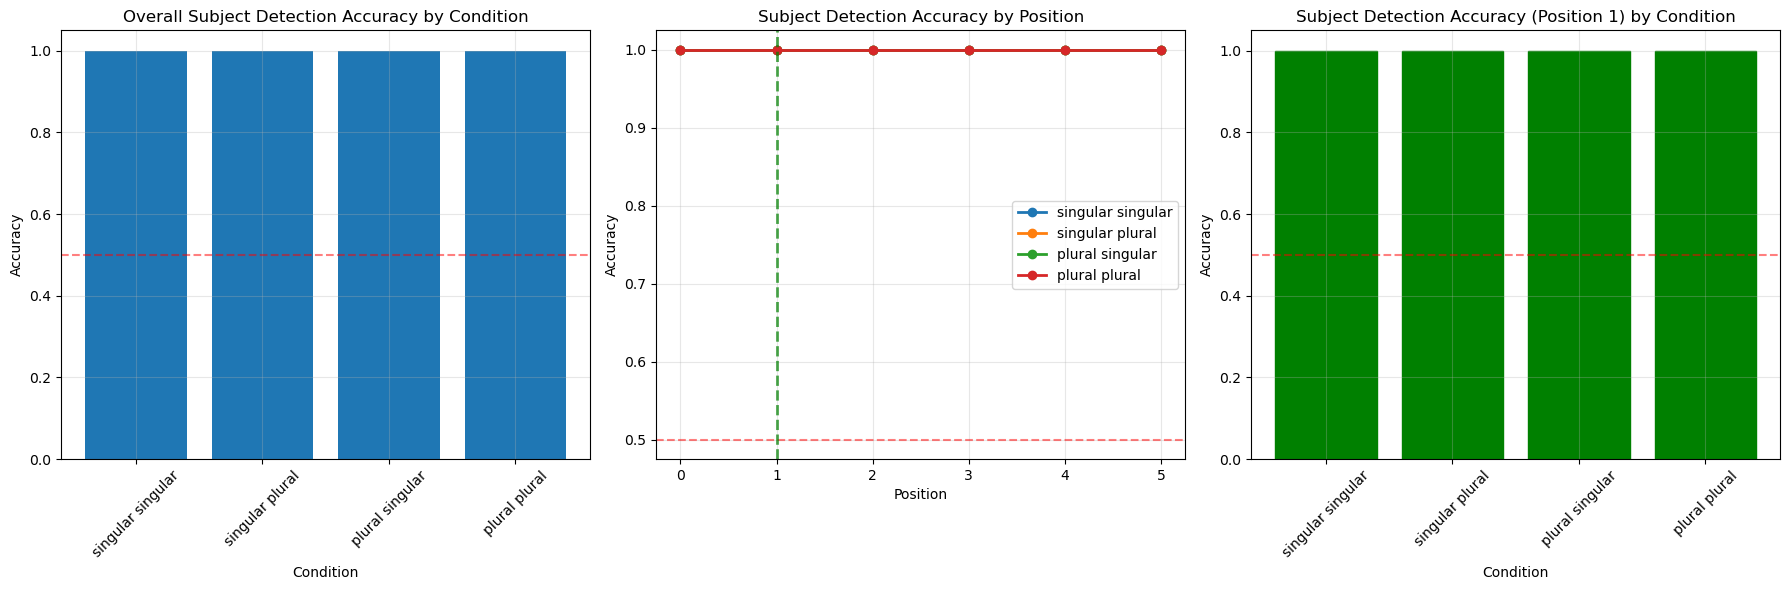

{'overall_accuracies': {'singular singular': 1.0,
  'singular plural': 1.0,
  'plural singular': 1.0,
  'plural plural': 1.0},
 'subject_accuracies': {'singular singular': 1.0,
  'singular plural': 1.0,
  'plural singular': 1.0,
  'plural plural': 1.0}}

In [175]:
analyze_results(res)

In [176]:

# Main execution function
def run_subject_detection_analysis(features, targets, dataset, test_size=0.2):
    """
    Complete pipeline for subject detection analysis.
    """
    print("Step 1: Preparing features and targets by condition...")
    condition_data = prepare_features_and_targets(features, targets, dataset)
    
    print(f"Found {len(condition_data)} conditions:")
    for condition, data in condition_data.items():
        print(f"  {condition}: {data['X'].shape[0]} samples")
    
    print("\nStep 2: Training logistic regression classifiers...")
    results = train_logistic_regression_by_condition(condition_data, test_size=test_size)
    
    print("\nStep 3: Analyzing results...")
    summary_data = analyze_results(results)
    
    return results, summary_data



In [177]:
# Diagnostic functions to understand why accuracy is too high

def analyze_feature_patterns(condition_data):
    """
    Analyze patterns in the features that might make classification trivial.
    """
    print("DIAGNOSTIC ANALYSIS - Why is accuracy so high?")
    print("="*60)
    
    for condition, data in condition_data.items():
        print(f"\nCondition: {condition}")
        
        X = data['X']  # [n_samples, seq_len, hidden_dim]
        y = data['y']  # [n_samples, seq_len]
        
        n_samples, seq_len, hidden_dim = X.shape
        
        # Reshape for analysis
        X_reshaped = X.reshape(-1, hidden_dim)
        y_reshaped = y.reshape(-1)
        
        # Analyze differences between subject and non-subject representations
        subject_mask = y_reshaped == 1
        nonsubject_mask = y_reshaped == 0
        
        subject_features = X_reshaped[subject_mask]
        nonsubject_features = X_reshaped[nonsubject_mask]
        
        print(f"  Subject samples: {subject_features.shape[0]}")
        print(f"  Non-subject samples: {nonsubject_features.shape[0]}")
        
        # Check if there are obvious differences
        subject_mean = np.mean(subject_features, axis=0)
        nonsubject_mean = np.mean(nonsubject_features, axis=0)
        
        # Calculate mean absolute difference per dimension
        mean_diff = np.abs(subject_mean - nonsubject_mean)
        
        print(f"  Average absolute difference per dimension: {np.mean(mean_diff):.6f}")
        print(f"  Max difference in any dimension: {np.max(mean_diff):.6f}")
        print(f"  Dimensions with large differences (>0.1): {np.sum(mean_diff > 0.1)}")
        
        # Check if features are mostly zeros or have extreme values
        print(f"  Subject features - % zeros: {np.mean(subject_features == 0) * 100:.2f}%")
        print(f"  Non-subject features - % zeros: {np.mean(nonsubject_features == 0) * 100:.2f}%")
        
        # Check standard deviations
        subject_std = np.std(subject_features, axis=0)
        nonsubject_std = np.std(nonsubject_features, axis=0)
        
        print(f"  Subject features - avg std: {np.mean(subject_std):.6f}")
        print(f"  Non-subject features - avg std: {np.mean(nonsubject_std):.6f}")



In [178]:
analyze_feature_patterns(condition_data)

DIAGNOSTIC ANALYSIS - Why is accuracy so high?

Condition: singular singular
  Subject samples: 1000
  Non-subject samples: 5000
  Average absolute difference per dimension: 0.138163
  Max difference in any dimension: 1.549140
  Dimensions with large differences (>0.1): 311
  Subject features - % zeros: 0.00%
  Non-subject features - % zeros: 0.00%
  Subject features - avg std: 0.135537
  Non-subject features - avg std: 0.185202

Condition: singular plural
  Subject samples: 1000
  Non-subject samples: 5000
  Average absolute difference per dimension: 0.140686
  Max difference in any dimension: 1.547702
  Dimensions with large differences (>0.1): 317
  Subject features - % zeros: 0.00%
  Non-subject features - % zeros: 0.00%
  Subject features - avg std: 0.136324
  Non-subject features - avg std: 0.186676

Condition: plural singular
  Subject samples: 1000
  Non-subject samples: 5000
  Average absolute difference per dimension: 0.152124
  Max difference in any dimension: 1.512335
  Dim

In [204]:
def test_simpler_baselines(condition_data):
    """
    Test if simpler baselines also achieve perfect accuracy.
    """
    print("\nBASELINE COMPARISONS")
    print("="*30)
    
    for condition, data in condition_data.items():
        print(f"\nCondition: {condition}")
        
        X = data['X']
        y = data['y']
        
        # Reshape
        X_reshaped = X.reshape(-1, X.shape[-1])
        y_reshaped = y.reshape(-1)
        
        # Split data
        train_sentences = np.arange(len(y))[:int(0.7 * len(y))]
        test_sentences = np.arange(len(y))[int(0.7 * len(y)):]
        
        sentence_indices = np.repeat(np.arange(len(y)), y.shape[1])
        train_mask = np.isin(sentence_indices, train_sentences)
        test_mask = np.isin(sentence_indices, test_sentences)
        
        X_train, X_test = X_reshaped[train_mask], X_reshaped[test_mask]
        y_train, y_test = y_reshaped[train_mask], y_reshaped[test_mask]
        
        # Test 1: Position-only baseline (just predict based on position)
        print("  Position-only baseline:", end=" ")
        position_preds = np.zeros_like(y_test)
        # Predict position 1 as subject for each sentence
        for i, sent_idx in enumerate(sentence_indices[test_mask]):
            pos_in_sent = i % y.shape[1]
            if pos_in_sent == 1:
                position_preds[i] = 1
        pos_acc = accuracy_score(y_test, position_preds)
        print(f"{pos_acc:.4f}")
        
        # Test 2: Single feature baseline
        print("  Single best feature:", end=" ")
        best_acc = 0
        for feat_idx in range(X.shape[-1]):
            clf_single = LogisticRegression(random_state=42, max_iter=1000)
            clf_single.fit(X_train[:, feat_idx:feat_idx+1], y_train)
            single_pred = clf_single.predict(X_test[:, feat_idx:feat_idx+1])
            single_acc = accuracy_score(y_test, single_pred)
            print(single_acc)
            #best_acc = min(best_acc, single_acc)
        #print(f"{best_acc:.4f}")
        
        # Test 3: Mean feature baseline
        print("  Mean feature only:", end=" ")
        X_train_mean = np.mean(X_train, axis=1, keepdims=True)
        X_test_mean = np.mean(X_test, axis=1, keepdims=True)
        clf_mean = LogisticRegression(random_state=42, max_iter=1000)
        clf_mean.fit(X_train_mean, y_train)
        mean_pred = clf_mean.predict(X_test_mean)
        mean_acc = accuracy_score(y_test, mean_pred)
        print(f"{mean_acc:.4f}")



In [205]:
test_simpler_baselines(condition_data)


BASELINE COMPARISONS

Condition: singular singular
  Position-only baseline: 1.0000
  Single best feature: 0.8333333333333334
0.8294444444444444
0.8333333333333334
0.8333333333333334
0.8327777777777777
0.8333333333333334
0.8333333333333334
0.8538888888888889
0.8294444444444444
0.83
0.8227777777777778
0.8333333333333334
0.8333333333333334
0.8088888888888889
0.8333333333333334
0.8333333333333334
0.8333333333333334
0.8333333333333334
0.8333333333333334
0.8333333333333334
0.825
0.8333333333333334
0.8333333333333334
0.8294444444444444
0.8333333333333334
0.8333333333333334
0.8383333333333334
0.8333333333333334
0.8077777777777778
0.8333333333333334
0.8744444444444445
0.8511111111111112
0.8183333333333334
0.8333333333333334
0.8611111111111112
0.8027777777777778
0.8333333333333334
0.8333333333333334
0.8083333333333333
0.8066666666666666
0.8077777777777778
0.9283333333333333
0.8272222222222222
0.8227777777777778
0.8305555555555556
0.8761111111111111
0.8333333333333334
0.8333333333333334
0.83277

# Position encodes all the information about the subject sincez subject is always in the same positon

In [208]:
def run_controlled_experiment(condition_data):
    """
    Run experiments with controlled difficulty to see where the task becomes challenging.
    """
    print("\nCONTROLLED EXPERIMENTS")
    print("="*30)
    
    for condition, data in condition_data.items():
        print(f"\nCondition: {condition}")
        
        X = data['X']
        y = data['y']
        
        X_reshaped = X.reshape(-1, X.shape[-1])
        y_reshaped = y.reshape(-1)
        
        # Standard split
        sentence_indices = np.repeat(np.arange(len(y)), y.shape[1])
        train_sentences = np.arange(len(y))[:int(0.7 * len(y))]
        test_sentences = np.arange(len(y))[int(0.7 * len(y)):]
        train_mask = np.isin(sentence_indices, train_sentences)
        test_mask = np.isin(sentence_indices, test_sentences)
        
        X_train, X_test = X_reshaped[train_mask], X_reshaped[test_mask]
        y_train, y_test = y_reshaped[train_mask], y_reshaped[test_mask]
        
        # Experiment 1: Add noise to features
        print("  With 90% noise:", end=" ")
        noise_std = 0.9 * np.std(X_train)
        X_train_noisy = X_train + np.random.normal(0, noise_std, X_train.shape)
        X_test_noisy = X_test + np.random.normal(0, noise_std, X_test.shape)
        
        clf_noise = LogisticRegression(random_state=42, max_iter=1000)
        clf_noise.fit(X_train_noisy, y_train)
        noise_pred = clf_noise.predict(X_test_noisy)
        noise_acc = accuracy_score(y_test, noise_pred)
        print(f"{noise_acc:.4f}")
        
        # Experiment 2: Use only subset of features
        print("  With 1% of features:", end=" ")
        n_features = max(1, X.shape[-1] // 100)
        random_features = np.random.choice(X.shape[-1], n_features, replace=False)
        
        clf_subset = LogisticRegression(random_state=42, max_iter=1000)
        clf_subset.fit(X_train[:, random_features], y_train)
        subset_pred = clf_subset.predict(X_test[:, random_features])
        subset_acc = accuracy_score(y_test, subset_pred)
        print(f"{subset_acc:.4f}")
        
        # Experiment 3: Shuffle labels partially
        print("  With 20% label noise:", end=" ")
        y_train_shuffled = y_train.copy()
        shuffle_indices = np.random.choice(len(y_train), int(0.2 * len(y_train)), replace=False)
        y_train_shuffled[shuffle_indices] = 1 - y_train_shuffled[shuffle_indices]
        
        clf_shuffle = LogisticRegression(random_state=42, max_iter=1000)
        clf_shuffle.fit(X_train, y_train_shuffled)
        shuffle_pred = clf_shuffle.predict(X_test)
        shuffle_acc = accuracy_score(y_test, shuffle_pred)
        print(f"{shuffle_acc:.4f}")



In [209]:
run_controlled_experiment(condition_data)


CONTROLLED EXPERIMENTS

Condition: singular singular
  With 90% noise: 1.0000
  With 1% of features: 0.9250
  With 20% label noise: 0.9800

Condition: singular plural
  With 90% noise: 1.0000
  With 1% of features: 0.9933
  With 20% label noise: 0.9856

Condition: plural singular
  With 90% noise: 1.0000
  With 1% of features: 0.9278
  With 20% label noise: 0.9544

Condition: plural plural
  With 90% noise: 1.0000
  With 1% of features: 0.9300
  With 20% label noise: 0.8828


In [183]:
# Updated main function with diagnostics
def run_subject_detection_analysis_with_diagnostics(features, targets, dataset, test_size=0.2):
    """
    Complete pipeline with diagnostic analysis for perfect accuracy.
    """
    print("Step 1: Preparing features and targets by condition...")
    condition_data = prepare_features_and_targets(features, targets, dataset)
    
    print(f"Found {len(condition_data)} conditions:")
    for condition, data in condition_data.items():
        print(f"  {condition}: {data['X'].shape[0]} samples")
    
    # Run diagnostics first
    analyze_feature_patterns(condition_data)
    test_simpler_baselines(condition_data)
    run_controlled_experiment(condition_data)
    
    print("\nStep 2: Training logistic regression classifiers...")
    results = train_logistic_regression_by_condition(condition_data, test_size=test_size)
    
    print("\nStep 3: Analyzing results...")
    summary_data = analyze_results(results)
    
    return results, summary_data, condition_data

# Usage:
# results, summary, condition_data = run_subject_detection_analysis_with_diagnostics(features, targets, dataset)

In [184]:
results, summary, condition_data = run_subject_detection_analysis_with_diagnostics(features, targets, dataset)

Step 1: Preparing features and targets by condition...


TypeError: prepare_features_and_targets() takes 2 positional arguments but 3 were given

In [199]:
def cross_position_subject_detection(condition_data):
    """
    Train on positions 0,2,3,4,5 and test on position 1 (subject position).
    This tests if the model learns 'subject-ness' beyond just position.
    """
    print("TASK 1: Cross-Position Subject Detection")
    print("="*50)
    print("Training on all positions EXCEPT position 4 (attractor), testing on position 4(attractor)")
    
    results = {}
    
    for condition, data in condition_data.items():
        print(f"\nCondition: {condition}")
        
        X = data['X']  # [n_samples, seq_len, hidden_dim]
        y = data['y']  # [n_samples, seq_len]
        
        # Create training data from all positions except position 1
        train_positions = [0, 1, 2, 3, 5]  # All except position 1
        test_position = 4  # Subject position
        
        # Extract training data (all sentences, specific positions)
        X_train_list = []
        y_train_list = []
        
        for pos in train_positions:
            X_train_list.append(X[:, pos, :])  # All samples, position pos
            y_train_list.append(y[:, pos])     # All samples, position pos
        
        X_train = np.concatenate(X_train_list, axis=0)
        y_train = np.concatenate(y_train_list, axis=0)
        
        # Extract test data (all sentences, position 1 only)
        X_test = X[:, test_position, :]  # All samples, position 1
        y_test = y[:, test_position]     # All samples, position 1
        
        print(f"  Train samples: {len(X_train)} (from positions {train_positions})")
        print(f"  Test samples: {len(X_test)} (from position {test_position})")
        print(f"  Train label distribution: {np.bincount(y_train.astype(int))}")
        print(f"  Test label distribution: {np.bincount(y_test.astype(int))}")
        print(np.unique(y_train))
        # Train classifier
        clf = LogisticRegression(random_state=42, max_iter=1000)
        clf.fit(X_train, y_train)
        
        # Test on position 1
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        results[condition] = {
            'accuracy': accuracy,
            'classifier': clf,
            'y_test': y_test,
            'y_pred': y_pred
        }
        
        print(f"  Cross-position accuracy: {accuracy:.4f}")
        
    return results

In [200]:
cross_position_subject_detection(condition_data)

TASK 1: Cross-Position Subject Detection
Training on all positions EXCEPT position 4 (attractor), testing on position 4(attractor)

Condition: singular singular
  Train samples: 5000 (from positions [0, 1, 2, 3, 5])
  Test samples: 1000 (from position 4)
  Train label distribution: [4000 1000]
  Test label distribution: [1000]
[0 1]
  Cross-position accuracy: 0.0000

Condition: singular plural
  Train samples: 5000 (from positions [0, 1, 2, 3, 5])
  Test samples: 1000 (from position 4)
  Train label distribution: [4000 1000]
  Test label distribution: [1000]
[0 1]
  Cross-position accuracy: 0.0000

Condition: plural singular
  Train samples: 5000 (from positions [0, 1, 2, 3, 5])
  Test samples: 1000 (from position 4)
  Train label distribution: [4000 1000]
  Test label distribution: [1000]
[0 1]
  Cross-position accuracy: 0.0000

Condition: plural plural
  Train samples: 5000 (from positions [0, 1, 2, 3, 5])
  Test samples: 1000 (from position 4)
  Train label distribution: [4000 1000]

{'singular singular': {'accuracy': 0.0,
  'classifier': LogisticRegression(max_iter=1000, random_state=42),
  'y_test': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
         0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

Donc il doit y avoir similarité plus grande entre l'attracteur et le verbe qu'entre l'attracteur et le reste ? 

In [187]:
# Task 2: Syntactic role detection (across different sentence structures)
def syntactic_role_detection(condition_data):
    """
    Train on some conditions, test on others to see if syntactic role
    understanding generalizes across different sentence structures.
    """
    print("\nTASK 2: Cross-Condition Syntactic Role Detection")
    print("="*50)
    print("Training on some conditions, testing on others")
    
    conditions = list(condition_data.keys())
    results = {}
    
    # Test different train/test condition splits
    for test_condition in conditions:
        train_conditions = [c for c in conditions if c != test_condition]
        print(f"\nTrain on: {train_conditions}")
        print(f"Test on: {test_condition}")
        
        # Collect training data from train conditions
        X_train_list = []
        y_train_list = []
        
        for train_cond in train_conditions:
            X_cond = condition_data[train_cond]['X']
            y_cond = condition_data[train_cond]['y']
            
            # Use all positions from training conditions
            X_train_list.append(X_cond.reshape(-1, X_cond.shape[-1]))
            y_train_list.append(y_cond.reshape(-1))
        
        X_train = np.concatenate(X_train_list, axis=0)
        y_train = np.concatenate(y_train_list, axis=0)
        
        # Test data from test condition
        X_test_cond = condition_data[test_condition]['X']
        y_test_cond = condition_data[test_condition]['y']
        
        X_test = X_test_cond.reshape(-1, X_test_cond.shape[-1])
        y_test = y_test_cond.reshape(-1)
        
        print(f"  Train samples: {len(X_train)}")
        print(f"  Test samples: {len(X_test)}")
        
        # Train classifier
        clf = LogisticRegression(random_state=42, max_iter=1000)
        clf.fit(X_train, y_train)
        
        # Test
        y_pred = clf.predict(X_test)
        accuracy = accuracy_score(y_test, y_pred)
        
        results[test_condition] = {
            'accuracy': accuracy,
            'train_conditions': train_conditions,
            'classifier': clf
        }
        
        print(f"  Cross-condition accuracy: {accuracy:.4f}")
    
    return results

In [188]:
syntactic_role_detection(condition_data)


TASK 2: Cross-Condition Syntactic Role Detection
Training on some conditions, testing on others

Train on: ['singular plural', 'plural singular', 'plural plural']
Test on: singular singular
  Train samples: 18000
  Test samples: 6000
  Cross-condition accuracy: 1.0000

Train on: ['singular singular', 'plural singular', 'plural plural']
Test on: singular plural
  Train samples: 18000
  Test samples: 6000
  Cross-condition accuracy: 1.0000

Train on: ['singular singular', 'singular plural', 'plural plural']
Test on: plural singular
  Train samples: 18000
  Test samples: 6000
  Cross-condition accuracy: 1.0000

Train on: ['singular singular', 'singular plural', 'plural singular']
Test on: plural plural
  Train samples: 18000
  Test samples: 6000
  Cross-condition accuracy: 1.0000


{'singular singular': {'accuracy': 1.0,
  'train_conditions': ['singular plural', 'plural singular', 'plural plural'],
  'classifier': LogisticRegression(max_iter=1000, random_state=42)},
 'singular plural': {'accuracy': 1.0,
  'train_conditions': ['singular singular',
   'plural singular',
   'plural plural'],
  'classifier': LogisticRegression(max_iter=1000, random_state=42)},
 'plural singular': {'accuracy': 1.0,
  'train_conditions': ['singular singular',
   'singular plural',
   'plural plural'],
  'classifier': LogisticRegression(max_iter=1000, random_state=42)},
 'plural plural': {'accuracy': 1.0,
  'train_conditions': ['singular singular',
   'singular plural',
   'plural singular'],
  'classifier': LogisticRegression(max_iter=1000, random_state=42)}}

In [189]:
def position_invariant_probing(condition_data):
    """
    Remove positional information by training classifier to be position-invariant.
    """
    print("\nTASK 3: Position-Invariant Subject Detection")
    print("="*50)
    print("Training with position information removed/balanced")
    
    results = {}
    
    for condition, data in condition_data.items():
        print(f"\nCondition: {condition}")
        
        X = data['X']  # [n_samples, seq_len, hidden_dim]
        y = data['y']  # [n_samples, seq_len]
        
        # Method 1: Remove position embeddings (if they're explicit)
        # We'll try to make the classifier position-invariant by
        # training it to ignore position information
        
        # Reshape data
        X_reshaped = X.reshape(-1, X.shape[-1])
        y_reshaped = y.reshape(-1)
        
        # Create position labels
        position_labels = np.repeat(np.arange(X.shape[1]), X.shape[0])
        
        # Split data
        train_indices = np.random.choice(len(X_reshaped), 
                                        size=int(0.7 * len(X_reshaped)), 
                                        replace=False)
        test_indices = np.setdiff1d(np.arange(len(X_reshaped)), train_indices)
        
        X_train, X_test = X_reshaped[train_indices], X_reshaped[test_indices]
        y_train, y_test = y_reshaped[train_indices], y_reshaped[test_indices]
        pos_train, pos_test = position_labels[train_indices], position_labels[test_indices]
        
        # Train a classifier that tries to be position-invariant
        # We'll use adversarial training approach conceptually
        
        # First, find features that are most correlated with position
        from sklearn.feature_selection import mutual_info_classif
        
        pos_info = mutual_info_classif(X_train, pos_train, random_state=42)
        # Remove top 10% most position-correlated features
        pos_corr_threshold = np.percentile(pos_info, 90)
        position_invariant_features = pos_info < pos_corr_threshold
        
        print(f"  Using {np.sum(position_invariant_features)} position-invariant features")
        print(f"  (removed {np.sum(~position_invariant_features)} position-correlated features)")
        
        # Train on position-invariant features
        clf = LogisticRegression(random_state=42, max_iter=1000)
        clf.fit(X_train[:, position_invariant_features], y_train)
        
        # Test
        y_pred = clf.predict(X_test[:, position_invariant_features])
        accuracy = accuracy_score(y_test, y_pred)
        
        results[condition] = {
            'accuracy': accuracy,
            'n_features_used': np.sum(position_invariant_features),
            'n_features_removed': np.sum(~position_invariant_features),
            'classifier': clf
        }
        
        print(f"  Position-invariant accuracy: {accuracy:.4f}")
    
    return results

In [190]:
position_invariant_probing(condition_data)


TASK 3: Position-Invariant Subject Detection
Training with position information removed/balanced

Condition: singular singular
  Using 585 position-invariant features
  (removed 65 position-correlated features)
  Position-invariant accuracy: 1.0000

Condition: singular plural
  Using 585 position-invariant features
  (removed 65 position-correlated features)
  Position-invariant accuracy: 1.0000

Condition: plural singular
  Using 585 position-invariant features
  (removed 65 position-correlated features)
  Position-invariant accuracy: 1.0000

Condition: plural plural
  Using 585 position-invariant features
  (removed 65 position-correlated features)
  Position-invariant accuracy: 1.0000


{'singular singular': {'accuracy': 1.0,
  'n_features_used': 585,
  'n_features_removed': 65,
  'classifier': LogisticRegression(max_iter=1000, random_state=42)},
 'singular plural': {'accuracy': 1.0,
  'n_features_used': 585,
  'n_features_removed': 65,
  'classifier': LogisticRegression(max_iter=1000, random_state=42)},
 'plural singular': {'accuracy': 1.0,
  'n_features_used': 585,
  'n_features_removed': 65,
  'classifier': LogisticRegression(max_iter=1000, random_state=42)},
 'plural plural': {'accuracy': 1.0,
  'n_features_used': 585,
  'n_features_removed': 65,
  'classifier': LogisticRegression(max_iter=1000, random_state=42)}}

In [201]:
def semantic_probing(condition_data):
    """
    Test if subject representations are more similar to each other
    than to non-subjects, regardless of position.
    """
    print("\nTASK 4: Semantic Similarity Analysis")
    print("="*50)
    
    from sklearn.metrics.pairwise import cosine_similarity
    
    results = {}
    
    for condition, data in condition_data.items():
        print(f"\nCondition: {condition}")
        
        X = data['X']
        y = data['y']
        
        # Get all subject and non-subject representations
        X_reshaped = X.reshape(-1, X.shape[-1])
        y_reshaped = y.reshape(-1)
        
        subject_reps = X_reshaped[y_reshaped == 1]
        nonsubject_reps = X_reshaped[y_reshaped == 0]
        #attractor_reps = X_reshaped[y_reshaped==4]
        
        # Calculate similarities
        # Subject-subject similarity
        subj_subj_sim = cosine_similarity(subject_reps)
        subj_subj_mean = np.mean(subj_subj_sim[np.triu_indices_from(subj_subj_sim, k=1)])
        
        # Non-subject to non-subject similarity
        nonsubj_nonsubj_sim = cosine_similarity(nonsubject_reps)
        nonsubj_nonsubj_mean = np.mean(nonsubj_nonsubj_sim[np.triu_indices_from(nonsubj_nonsubj_sim, k=1)])
        
        # Subject to non-subject similarity
        subj_nonsubj_sim = cosine_similarity(subject_reps, nonsubject_reps)
        subj_nonsubj_mean = np.mean(subj_nonsubj_sim)
        
        # #subject to attractor similarity
        # subj_attr_sim = cosine_similarity(subject_reps, attractor_reps)
        # subj_attr_mean = np.mean(subj_attr_sim[np.triu_indices_from(subj_attr_sim, k=1)])
        
        # #attractor to non subject similairty
        
        results[condition] = {
            'subject_subject_similarity': subj_subj_mean,
            'nonsubject_nonsubject_similarity': nonsubj_nonsubj_mean,
            'subject_nonsubject_similarity': subj_nonsubj_mean,
            #'subject_attractor_similarity': subj_attr_mean
        }
        
        print(f"  Subject-Subject similarity: {subj_subj_mean:.4f}")
        print(f"  NonSubject-NonSubject similarity: {nonsubj_nonsubj_mean:.4f}")
        print(f"  Subject-NonSubject similarity: {subj_nonsubj_mean:.4f}")
        #print(f"  Subject-Attractor similarity: {subj_attr_mean:.4f}")
        
        # The key test: are subjects more similar to each other than to non-subjects?
        if subj_subj_mean > subj_nonsubj_mean:
            print(f"  ✓ Subjects are more similar to each other than to non-subjects")
        else:
            print(f"  ✗ No clear subject clustering")
    
    return results
    

In [192]:
semantic_probing(condition_data)


TASK 4: Semantic Similarity Analysis

Condition: singular singular
  Subject-Subject similarity: 0.7193
  NonSubject-NonSubject similarity: 0.2324
  Subject-NonSubject similarity: 0.1182
  ✓ Subjects are more similar to each other than to non-subjects

Condition: singular plural
  Subject-Subject similarity: 0.7170
  NonSubject-NonSubject similarity: 0.2178
  Subject-NonSubject similarity: 0.1019
  ✓ Subjects are more similar to each other than to non-subjects

Condition: plural singular
  Subject-Subject similarity: 0.7171
  NonSubject-NonSubject similarity: 0.2058
  Subject-NonSubject similarity: 0.0762
  ✓ Subjects are more similar to each other than to non-subjects

Condition: plural plural
  Subject-Subject similarity: 0.7225
  NonSubject-NonSubject similarity: 0.2017
  Subject-NonSubject similarity: 0.0897
  ✓ Subjects are more similar to each other than to non-subjects


{'singular singular': {'subject_subject_similarity': 0.71928716,
  'nonsubject_nonsubject_similarity': 0.23244534,
  'subject_nonsubject_similarity': 0.11822364},
 'singular plural': {'subject_subject_similarity': 0.716974,
  'nonsubject_nonsubject_similarity': 0.21782742,
  'subject_nonsubject_similarity': 0.10194903},
 'plural singular': {'subject_subject_similarity': 0.7170666,
  'nonsubject_nonsubject_similarity': 0.20578894,
  'subject_nonsubject_similarity': 0.07616307},
 'plural plural': {'subject_subject_similarity': 0.72254556,
  'nonsubject_nonsubject_similarity': 0.20170175,
  'subject_nonsubject_similarity': 0.08970763}}

Now let's do semantic probing with attractor subject and the rest